Create a K-means clustering algorithm to group customers of a retail store based on their purchase history.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Mall_Customers.csv')

In [5]:
X = df[['Annual Income (k$)','Spending Score (1-100)']].values
print(X.shape)

(200, 2)


In [11]:
means = X.mean(axis=0)
stds = X.std(axis=0)
X_scaled = (X - means)/stds
print(X_scaled[:3])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]]


In [12]:
K = 5
np.random.seed(42)

# --- pick the very first centroid randomly ---
first_index = np.random.randint(0, len(X_scaled))
centroids   = [X_scaled[first_index]]

# --- pick the remaining K-1 centroids one by one ---
for _ in range(K - 1):

    distances = []

    # for every point in the dataset...
    for point in X_scaled:

        # find its distance to each centroid we already have
        d_to_each = []
        for c in centroids:
            diff = point - c
            d    = np.sqrt(np.sum(diff ** 2))
            d_to_each.append(d)

        # keep only the CLOSEST distance
        closest = min(d_to_each)
        distances.append(closest)

    distances = np.array(distances)

    # square the distances  →  far-away points get more weight
    weights = distances ** 2

    # turn weights into probabilities that sum to 1
    probs = weights / weights.sum()

    # randomly pick the next centroid using those probabilities
    next_index = np.random.choice(len(X_scaled), p=probs)
    centroids.append(X_scaled[next_index])

centroids = np.array(centroids)
print("Starting centroids shape:", centroids.shape)  # (5, 2)

Starting centroids shape: (5, 2)


In [13]:
def assign_points(X_scaled, centroids):

    labels = []   # will store one cluster number per point

    for point in X_scaled:

        distances = []

        # measure distance from this point to every centroid
        for c in centroids:
            diff     = point - c
            distance = np.sqrt(np.sum(diff ** 2))
            distances.append(distance)

        # the cluster with the smallest distance wins
        nearest_cluster = np.argmin(distances)
        labels.append(nearest_cluster)

    return np.array(labels)


labels = assign_points(X_scaled, centroids)
print("First 10 labels:", labels[:10])


First 10 labels: [4 2 4 2 4 2 4 2 4 2]


In [14]:
def move_centroids(X_scaled, labels, K):

    new_centroids = []

    for k in range(K):

        # collect all points that belong to cluster k
        members = []
        for i in range(len(X_scaled)):
            if labels[i] == k:
                members.append(X_scaled[i])

        members = np.array(members)

        # new centroid = average position of all members
        avg = members.mean(axis=0)
        new_centroids.append(avg)

    return np.array(new_centroids)


centroids = move_centroids(X_scaled, labels, K)
print("Updated centroids:", centroids)


Updated centroids: [[ 0.02758156  0.30449607]
 [ 1.16717873 -1.08506262]
 [-1.38342083  1.20796351]
 [ 1.04171441  1.41425508]
 [-0.62678444 -0.50112165]]


In [15]:
for iteration in range(100):

    # step 4 — assign points to nearest centroid
    new_labels = assign_points(X_scaled, centroids)

    # count how many points switched cluster
    changes = 0
    for i in range(len(labels)):
        if new_labels[i] != labels[i]:
            changes += 1

    # update labels
    labels = new_labels

    # step 5 — move centroids to new averages
    centroids = move_centroids(X_scaled, labels, K)

    print(f"Iteration {iteration + 1}  →  {changes} points changed")

    # if nothing changed, we are done
    if changes == 0:
        print("Converged! Stopping early.")
        break


Iteration 1  →  34 points changed
Iteration 2  →  23 points changed
Iteration 3  →  7 points changed
Iteration 4  →  2 points changed
Iteration 5  →  0 points changed
Converged! Stopping early.


Cluster 1:  81 customers
Cluster 2:  35 customers
Cluster 3:  22 customers
Cluster 4:  39 customers
Cluster 5:  23 customers


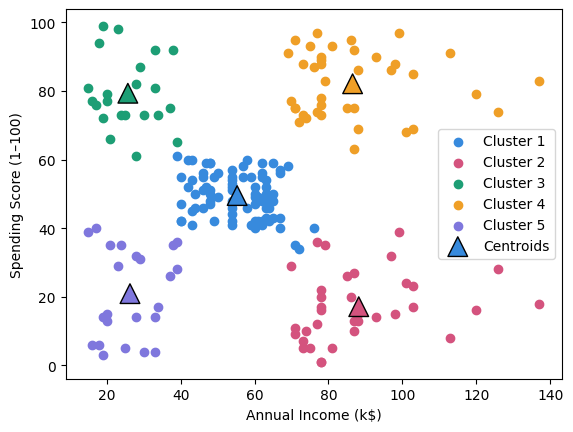

In [16]:
for k in range(K):
    count = 0
    for label in labels:
        if label == k:
            count += 1
    print(f"Cluster {k + 1}:  {count} customers")


# --- plot (use original X, not scaled, for readable axes) ---
import matplotlib.pyplot as plt

COLORS = ['#378ADD', '#D4537E', '#1D9E75', '#EF9F27', '#7F77DD']

for k in range(K):
    cluster_points = X[labels == k]
    plt.scatter(cluster_points[:, 0],
                cluster_points[:, 1],
                color=COLORS[k],
                label=f"Cluster {k + 1}")

# convert centroids back to original scale for the plot
centroids_original = centroids * stds + means

plt.scatter(centroids_original[:, 0],
            centroids_original[:, 1],
            marker='^', s=200,
            color=COLORS, edgecolors='black',
            label="Centroids")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1–100)")
plt.legend()
plt.show()

## Observations
We have observed 5 kinds of people here:
Cluster 1: Middle income, middle spend
Cluster 2: High income, low spend
Cluster 3: Low income, high spend
Cluster 4: High income, high spend
Cluster 5: Low income, low spend